# Chapter 06 — Black & Bachelier Swaption Pricing

# 1. Introduction
## 1.1 European Swaptions, Volatility Models, and Negative Rates

In this chapter we move from:

> linear rates products

to:

> nonlinear volatility derivatives.

We introduce:

- European swaptions
- Black's model
- Bachelier (normal) model
- implied volatility
- volatility smiles
- negative rates handling
- forward-starting swaps

This is the beginning of: 
### rates volatility modeling.

## 1.2 Why This Chapter Matters

Swaptions are among the most important derivatives in global fixed income markets.

Used heavily for:

- macro trading
- callable products
- structured notes
- Bermudan swaptions
- mortgage hedging
- XVA systems

This chapter introduces the foundations of:

- rates volatility surfaces
- smile models
- SABR calibration
- stochastic volatility

---


# 2. Import Libraries

In [3]:
import sys
sys.path.append("../python")

import numpy as np
import matplotlib.pyplot as plt

from curve import YieldCurve

from forward_swap import (
    ForwardStartingSwap
)

from black_swaption import (
    BlackSwaption
)

from bachelier_swaption import (
    BachelierSwaption
)

from greeks import vega

from implied_vol import (
    implied_volatility
)

from market_data import load_market_curve

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# 3. Swaption Concept
## 3.1 What is a Swaption?

A swaption is:

> an option on an interest rate swap.

The holder has:

- the right
- but not the obligation

to enter into a swap in the future.

## 3.2 Two Main Types

### Payer Swaption

Right to:

- pay fixed
- receive floating

Benefits when rates rise.

### Receiver Swaption

Right to:

- receive fixed
- pay floating

Benefits when rates fall.

### Why Swaptions Matter

Swaptions are central to:

- rates volatility trading
- callable exotics
- Bermudan pricing
- structured products
- mortgage hedging

## 3.3 Expiry × Tenor Structure

Market swaptions are quoted as:

```text
Expiry x Tenor
```

Example:

```text
1Y x 5Y
```

means:

- option expiry = 1Y
- underlying swap tenor = 5Y

### Important

This does NOT mean:

```text
0Y → 5Y swap
```

Instead:

the underlying swap starts in 1Y.


### Actual Underlying Swap

A:

```text
1Y x 5Y
```

swaption corresponds to a swap running from:

$$
1Y \rightarrow 6Y
$$

This is called:

### a forward-starting swap.

---

# 4. Loading Market Curve
We now load a simplified USD zero curve.

In production systems curves are built from:
- IS swaps
- futures
- IRS instruments
- treasury products
For educational purposes we use simplified data.

In [5]:
maturities, rates = load_market_curve(
    "../data/usd_zero_curve.csv"
)

curve = YieldCurve(
    maturities,
    rates
)

print("Curve loaded successfully.")

Curve loaded successfully.


## Plot Market zero curve

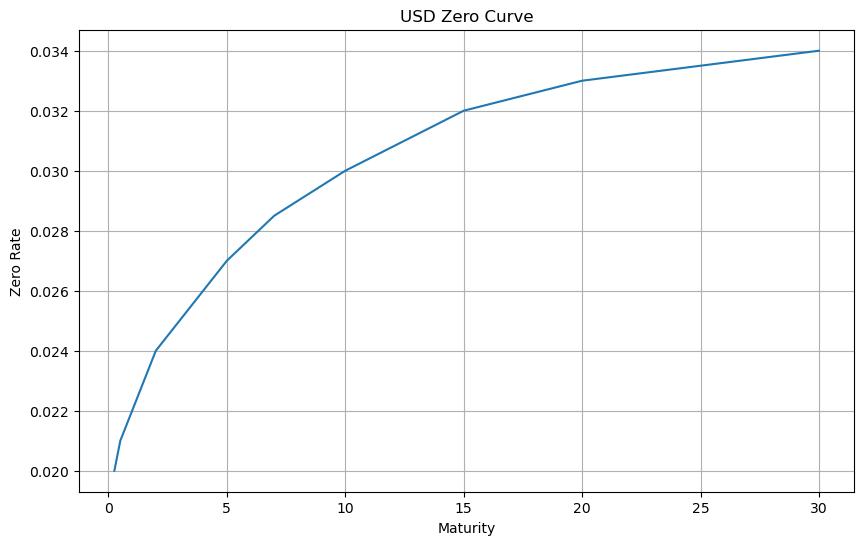

In [7]:
plt.figure()

plt.plot(
    maturities,
    rates
)

plt.title(
    "USD Zero Curve"
)

plt.xlabel(
    "Maturity"
)

plt.ylabel(
    "Zero Rate"
)

plt.grid()

plt.show()

---
# 5. Build Forward Starting Swap
We now construct:

```text
1Y x 5Y
```

underlying swap.

This means:

- swap starts at 1Y
- swap ends at 6Y

### Why This Matters

This is the correct underlying structure for European swaptions.

Many simplified tutorials incorrectly use:

```text
spot-starting swaps
```

which is not market standard.

In [8]:
swap = ForwardStartingSwap(
    notional=10_000_000,
    fixed_rate=0.03,
    start=1.0,
    end=6.0,
    payment_frequency=2
)

print(
    "Forward-starting swap created."
)

print(
    "Payment dates:"
)

print(
    swap.payment_dates
)

Forward-starting swap created.
Payment dates:
[1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]


---
# 6. Forward Swap Rate

Black's model uses:

$$
F = S(0;T_0,T_n)
$$

which is the:

### forward swap rate

NOT the spot swap rate $S(0; 0,T_n)$

## 6.1 Formula

$$
S(0;T_0,T_n) = \frac{ P(0,T_0)-P(0,T_n)}{\sum_i \Delta_i P(0,T_i)}
$$

where:

- $T_0$ = swap start
- $T_n$ = swap end

## 6.2 Important Insight

Even though the swap starts in the future:

we still discount using:
$$
P(0,T)
$$

because we are pricing the swaption at:
$$
t=0
$$

## 6.3 Computate Forward Swap Rate

In [9]:
forward_rate = swap.forward_swap_rate(
    curve
)

print(
    f"Forward Swap Rate = {forward_rate:.4%}"
)

Forward Swap Rate = 2.9018%


---
# 7. Swap Annuity

The annuity is:

$$
A(0) = \sum_i \Delta_i P(0,T_i)
$$

It represents:

> the PV of fixed-leg accrual payments.

The annuity is extremely important because:

swaption prices scale directly with annuity.

In [10]:
annuity = swap.annuity(curve)

print(
    f"Swap Annuity = {annuity:.6f}"
)

Swap Annuity = 4.535772


---
# 8. Black Swaption Model

The Black model assumes:

$$
dF = \sigma F dW
$$

This implies:

- lognormal forward swap rates
- strictly positive rates

## 8.1 Black Formula

For payer swaptions:
$$ 
Price = N \cdot A(F \cdot N(d_1)-K \cdot N(d_2))
$$

where:

$$
d_1=\frac{\ln(F/K)+\frac12 \sigma^2 T}{\sigma\sqrt{T}}
$$

$$
d_2=d_1-\sigma\sqrt{T}
$$

## 8.2 Important Limitation

Black breaks when:
$$
F \le 0
$$

because:
$$
\log(F/K)
$$
becomes invalid.

## 8.3 Build Black Swaption

In [33]:
black_swaption = BlackSwaption(
    notional=10_000_000,
    strike=0.03,
    expiry=1.0,
    underlying_swap=swap,
    volatility=0.20,
    payer=True
)

## 8.4 Price Black Swaption

In [34]:
black_price = black_swaption.price(
    curve
)

print(
    f"Black Swaption Price = ${black_price:,.2f}"
)

Black Swaption Price = $85,805.37


---
# 9. Bachelier (Normal) Model

After 2014 many rates became:
- near zero
- negative
This caused severe problems for Black's model.

## 9.1 Why Black Fails

Black assumes:

$$
F > 0
$$

because:
$$
\log(F/K)
$$
must exist.

Negative rates break this assumption.

## 9.2 Bachelier Dynamics

The Bachelier model assumes:

$$
dF = \sigma dW
$$

This means:

- normal rates
- rates can become negative

## 9.3 Why Bachelier Became Popular

Widely adopted for:
- EUR rates
- JPY rates
- CHF rates
especially during negative-rate regimes.

## 9.4 Build Bachelier Swaption

In [35]:
bachelier_swaption = BachelierSwaption(
    notional=10_000_000,
    strike=0.03,
    expiry=1.0,
    underlying_swap=swap,
    volatility=0.20,
    payer=True
)

## 9.5 Price Bachelier Swaption

In [36]:
bachelier_price = (
    bachelier_swaption.price(curve)
)

print(
    f"Bachelier Swaption Price = "
    f"${bachelier_price:,.2f}"
)

Bachelier Swaption Price = $3,596,787.54


---
# 10. Comparing Black vs Bachelier

We now compare the two models using:

- same curve
- same swap
- same expiry
- same strike

### The two models assume completely different dynamics.

## 10.1 Black Assumes

$$
dF = \sigma F dW
$$

This means:

- volatility scales with rates
- rates remain positive
- distribution is lognormal

## 10.2 Bachelier Assumes

$$
dF = \sigma dW
$$

This means:
- constant absolute volatility
- rates can be negative
- distribution is normal

## 10.3 Print Price Comparison

In [37]:
print(
    f"Black Price      = ${black_price:,.2f}"
)

print(
    f"Bachelier Price  = ${bachelier_price:,.2f}"
)

print(
    f"Difference        = "
    f"${bachelier_price-black_price:,.2f}"
)

Black Price      = $85,805.37
Bachelier Price  = $3,596,787.54
Difference        = $3,510,982.17


## 10.4 Why the Results Are Different

Even with identical inputs:
- probability distributions differ
- tail behavior differs
- rate dynamics differ

Therefore:

> the two models produce different swaption prices.

This is extremely important in rates volatility modeling.


### Black Model Characteristics

Black assumes:

$$
F_t > 0
$$

and:

$$
\frac{dF}{F}
$$

has constant volatility.

This creates:

- asymmetric distributions
- fat upside tails
- multiplicative dynamics

As rates increase:

absolute volatility also increases.


### Bachelier Characteristics

Bachelier assumes:

$$
dF
$$

has constant volatility.

This creates:

- symmetric distributions
- additive dynamics
- support for negative rates

### Important Intuition

When rates are low:

Black and Bachelier can produce significantly different prices.

This is especially true for:

- ATM swaptions
- low strikes
- negative-rate environments


### Real Market Practice

Different markets quote:

- Black implied vols
- normal vols

depending on:

- rate regime
- product type
- market convention


### Quant Insight

Production systems must support BOTH:

- Black vols
- normal vols

because market conventions vary globally.

---

# 11. Price vs Volatility Analysis

## 11.1 Construct Price-Volatility Data

In [40]:
vols = np.linspace(
    0.01,
    0.3,
    50
)

black_prices = []

for v in vols:

    black_swaption.volatility = v

    black_prices.append(
        black_swaption.price(curve)
    )

## 11.2 Plot Price-Volatility Relationship

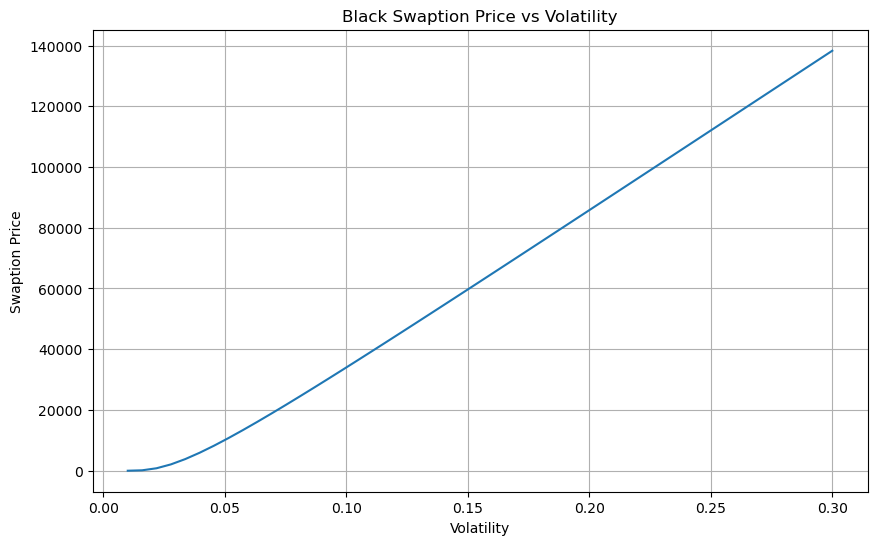

In [41]:
plt.figure()

plt.plot(
    vols,
    black_prices
)

plt.title(
    "Black Swaption Price vs Volatility"
)

plt.xlabel(
    "Volatility"
)

plt.ylabel(
    "Swaption Price"
)

plt.grid()

plt.show()

## 11.3 Why Is Price vs Volatility Almost Linear?

In the previous plot, we observed:

> swaption price increases almost linearly with volatility.

except near very low volatility levels.

This behavior is extremely important in volatility products.

### Intuition Behind the Shape

For ATM or near-ATM swaptions:

$$
Price \approx Vega \times \sigma
$$

This means:

- option value is approximately proportional to volatility
- increasing volatility increases uncertainty
- greater uncertainty increases option value

As a result:

$$
Price \propto \sigma
$$

which creates an almost linear relationship.


### Why the Curve Bends Near Zero Volatility

Near:

$$
\sigma \rightarrow 0
$$

the option approaches:

#### intrinsic value.

In this region:

- time value collapses
- probability distribution becomes degenerate
- small volatility changes have nonlinear effects

Therefore:

the curve is no longer perfectly linear near zero.


### Why Higher Volatility Produces Near-Linear Growth

For moderate volatility ranges:

- the option remains strongly vega-driven
- Black pricing becomes approximately affine in volatility

This is especially true for:

- ATM swaptions
- medium expiries
- moderate rate environments


### Quant Perspective

Large swaption books are often:

#### predominantly vega books.

This means:

small volatility changes can create nearly linear PnL moves.

This is why:

- vega hedging
- volatility surface management
- smile risk

are central to rates volatility trading desks.

## 11.4 Why ATM Swaptions Behave Like Pure Volatility Products

To understand why ATM swaptions are highly sensitive to volatility, consider the Black swaption formula:

$$
V = NA \left( F N(d_1) - K N(d_2) \right)
$$

where

$$
d_1 = \frac{\ln(F/K) +\frac12\sigma^2T}{\sigma\sqrt T}
$$

and

$$
d_2=d_1-\sigma\sqrt T
$$

### ATM Approximation

For an ATM swaption:

$$
F \approx K
$$

therefore

$$
\ln(F/K)\approx0
$$

which gives

$$
d_1 \approx \frac12\sigma\sqrt T,
\qquad
d_2 \approx -\frac12\sigma\sqrt T
$$

Using a first-order Taylor expansion of the normal CDF around zero:

$$
N(x)
\approx
\frac12
+
\frac{x}{\sqrt{2\pi}}
$$

the Black formula simplifies to

$$
V_{ATM}
\approx
NAF
\frac{
\sigma\sqrt T
}{
\sqrt{2\pi}
}
$$


### Why Is Price Nearly Linear in Volatility?

The ATM approximation shows:

$$
V_{ATM}
\propto
\sigma
$$

meaning the option value is approximately proportional to volatility.

As long as:

- expiry is fixed,
- forward rate is fixed,
- volatility is not extremely high,

the relationship between price and volatility is nearly linear.

This explains why the **Price vs Volatility** plot appears almost as a straight line.


### ATM Vega

Differentiating with respect to volatility gives:

$$
Vega_{ATM} = NAF \frac{\sqrt T}{\sqrt{2\pi}}
$$

which is approximately constant under the ATM approximation.

As a result:

- each additional 1% of volatility adds roughly the same amount of value,
- the price-volatility curve remains nearly linear.

### Why ATM Vega Is Largest

The exact Black vega is

$$
Vega = NA\phi(d_1)\sqrt T
$$

where

$$
\phi(x) =
\frac1{\sqrt{2\pi}}
e^{-x^2/2}
$$

Since $\phi(d_1)$ reaches its maximum at $d_1=0$, vega is largest when the option is close to ATM.

Therefore:

$$
Vega_{ATM}
>
Vega_{ITM},
\qquad
Vega_{ATM}
>
Vega_{OTM}
$$


### Quant Interpretation

ATM swaptions are often viewed as **pure volatility instruments** because:

- they have the highest vega,
- their value depends strongly on volatility,
- they are the most liquid points on the volatility surface,
- they anchor most volatility surface calibrations.

This is why ATM volatility is typically the first quantity traders monitor and hedge.

---
# 12. Vega Theory

Vega measures:

> sensitivity to volatility.

Formula:

$$
Vega = \frac{\partial V}{\partial \sigma}
$$

##  12.1 Why Vega Matters

Swaptions are primarily:

### volatility products.

Large swaption books are managed heavily through:

- vega
- smile risk
- surface risk

## 12.2 Compute Vega

In [42]:
# black_swaption.volatility = 0.20

swaption_vega = vega(
    black_swaption,
    curve
)

print(
    f"Swaption Vega = "
    f"{swaption_vega:,.2f}"
)

Swaption Vega = 524,677.02


---
# 13. Volatility Smile

Real market implied volatilities vary by strike.

This creates:

- volatility smiles
- volatility skews

Black's model assumes:

```text
flat volatility
```

which is unrealistic.

## 13.1 Why This Matters

Volatility smiles are central to:

- rates options trading
- SABR calibration
- exotic pricing

## 13.2 Build Smile Data

In [58]:
strikes = np.linspace(
    0.01,
    0.06,
    15
)

market_prices = []

for K in strikes:

    temp_swaption = BlackSwaption(
        notional=10_000_000,
        strike=K,
        expiry=1.0,
        underlying_swap=swap,
        volatility = 0.20+2.0*(K-0.03)**2,
        payer=True
    )

    market_prices.append(
        temp_swaption.price(curve)
    )

## 13.3 Generate Implied Volatility Data

In [66]:
implied_vols = []

for K, market_price in zip(
    strikes,
    market_prices
):

    calib_swaption = BlackSwaption(
        notional=10_000_000,
        strike=K,
        expiry=1.0,
        underlying_swap=swap,
        volatility=0.20,  # this setting here is arbitrary and meanningless
        payer=True
    )

    iv = implied_volatility(
        target_price=market_price,
        curve=curve,
        swaption=calib_swaption
    )

    implied_vols.append(iv)

## 13.4 Plot Volatility Smile

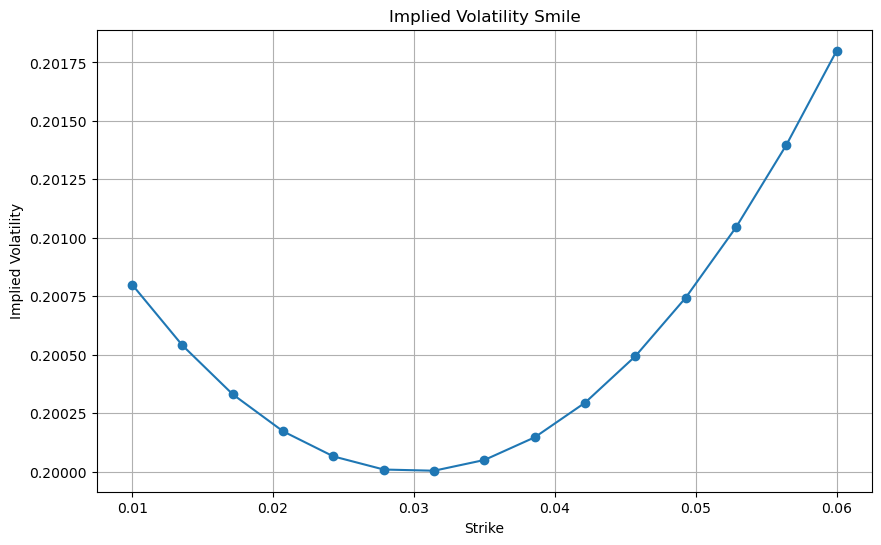

In [64]:
plt.figure()

plt.plot(
    strikes,
    implied_vols,
    marker='o'
)

plt.title(
    "Implied Volatility Smile"
)

plt.xlabel("Strike")

plt.ylabel("Implied Volatility")

plt.grid()

plt.show()

## 13.5 Why Is the Smile Symmetric Instead of Skewed?

In our example, the volatility smile appears:

#### symmetric.

This was intentional for visualization purposes.

In Section 13.2, we constructed the smile using:

$$
\sigma(K) = 0.20 + 5(K-0.03)^2
$$

#### which is NOT real market data and mathematically symmetric around:

$$
K = 3\%
$$

Therefore:
- low strikes have higher vol
- high strikes have higher vol
- equal-distance strikes have identical vols

This creates a perfectly symmetric smile.


### Real Market Smiles Are Usually NOT Symmetric

Actual swaption markets often exhibit:

- skew
- asymmetric smiles
- wing effects

This means:

$$
\sigma(K) \neq \sigma(2K_{ATM}-K)
$$


### Why Real Markets Exhibit Skew

Market skew arises because:

- rate distributions are not symmetric
- supply/demand differs by strike
- tail hedging demand is asymmetric
- macro risks are directional

Examples:

- callable desks may heavily buy receivers
- mortgage hedgers may concentrate in certain strikes
- central bank risk creates asymmetric tail fears

### Typical Rates Market Behavior

Historically:

- receiver skew often becomes elevated during risk-off periods
- payer skew can rise during inflation fears

Therefore:

the volatility surface contains important macro information.

### Why We Used a Symmetric Smile Here

For educational purposes:

a symmetric smile helps isolate:

### pure smile mechanics

without introducing:

- skew dynamics
- asymmetry effects
- calibration complexity

In the next chapters we will move toward:

- realistic skewed smiles
- SABR-generated skews
- market-calibrated volatility surfaces

---
# 14. Negative Rates Experiment

We now create a negative-rate environment.

This demonstrates:

- Black model instability
- Bachelier robustness

## 14.1 Create Negative Rate Curve

In [55]:
negative_rates = np.array([
    -0.007,
    -0.006,
    -0.005,
    -0.004,
    -0.003,
    -0.002,
    -0.001,
    0.000,
    0.001,
    0.002,
    0.003
])

negative_curve = YieldCurve(
    maturities,
    negative_rates
)

## 14.2 Attempt Black Pricing

In [56]:
try:

    black_swaption.price(
        negative_curve
    )

except Exception as e:

    print(
        "Black model failed:"
    )

    print(e)

Black model failed:
Black model invalid for negative rates.


## 14.3 Price Bachelier Under Negative Rates

In [57]:
negative_bachelier = (
    bachelier_swaption.price(
        negative_curve
    )
)

print(
    f"Bachelier Price "
    f"(negative rates) = "
    f"${negative_bachelier:,.2f}"
)

Bachelier Price (negative rates) = $3,296,495.55


---
# 15. Summary 
## 15.1 Chapter Summary

In this chapter we implemented:

- forward-starting swaps
- Black swaption pricing
- Bachelier swaption pricing
- implied volatility
- vega
- volatility smiles
- negative-rate handling

We introduced:

- forward swap rates
- annuities
- lognormal volatility
- normal volatility
- smile dynamics

## 15.2 Why This Chapter Matters

This chapter is foundational for:

- SABR calibration
- Bermudan swaptions
- callable exotics
- Monte Carlo rates models

## 15.3 Important Industry Insight

We learned:

- Black fails under negative rates
- Bachelier handles low-rate regimes
- market conventions matter heavily
- volatility modeling is central to rates derivatives
- 
Most real-world swaption systems are vastly more complex than textbook Black formulas.

Production systems require:

- calibration infrastructure
- surface management
- smile interpolation
- scenario risk
- cross-greeks
- real-time market updates

## 15.4 Next Chapters

### 07_Local Volatility and Dupire Model

We will introduce:

- local volatility surfaces
- Dupire equation
- strike-dependent volatility
- implied volatility inversion
- local volatility extraction

This chapter bridges the gap between:

- simple Black volatility
- full stochastic volatility models


### 08_SABR Volatility Surface Calibration

We will build:

- SABR volatility models
- smile calibration
- skew dynamics
- stochastic volatility surfaces

This moves us toward:

> realistic production-grade rates volatility modeling.